In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, skew, mannwhitneyu
import statsmodels.stats.power as smp

In [12]:
# Load the data.
df = pd.read_excel('Time_for_Bac_Fix_All_Subjects.xlsx')
df.head()

,Normal Equation,No R_a with Conj,No R_a No Conj
0,20573,15281,24167.0
1,20744,20808,20031.0
2,18912,11858,17489.0
3,20909,24331,21330.0
4,27044,19085,19687.0


### Descriptive Statistics

In [39]:
df.describe()

,Normal Equation,No R_a with Conj,No R_a No Conj
count,20.000000,20.000000,10.000000
mean,19518.300000,19037.950000,20592.400000
std,4788.567406,3129.338579,1837.434818
min,5111.000000,11858.000000,17489.000000
25%,17671.500000,17982.500000,19773.000000
50%,18876.000000,18873.000000,20399.500000
75%,21066.750000,20868.000000,21382.500000
max,29459.000000,24331.000000,24167.000000


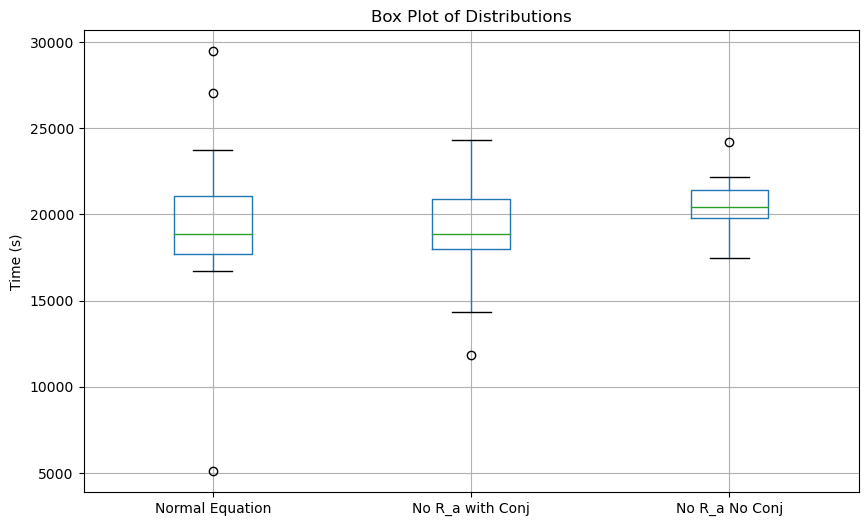

In [40]:
# Step 1: Visualize the Data
plt.figure(figsize=(10, 6))
df.boxplot()
plt.title('Box Plot of Distributions')
plt.ylabel('Time (s)')
plt.show()

In [ ]:
# Step 3: Statistical Test
t_stat, p_value = ttest_ind(df['Normal Equation'], df.dropna()['No R_a No Conj'])

print(descriptive_stats)
print(f"t-stat = {t_stat}")
print(f"p value = {p_value}")

In [26]:
# Calculate Skewness of a data set.
skew_normal = skew(df['Normal Equation'])
skew_no_ra_no_conj = skew(df['No R_a No Conj'].dropna())

# Step 3: Mann-Whitney U Test
u_stat, p_value_u = mannwhitneyu(df['Normal Equation'], df['No R_a No Conj'].dropna())

skew_normal, skew_no_ra_no_conj, u_stat, p_value_u

(-0.7637545759696468, 0.27136880449342954, 76.0, 0.30120060673958793)

In [35]:
# Calculate pooled standard deviation
n1 = df.shape[0]
n2 = df['No R_a No Conj'].dropna().shape[0]
s_p = np.sqrt(((n1 - 1) * std_normal**2 + (n2 - 1) * std_no_Ra_no_conj**2) / (n1 + n2 - 2))

# Calculate Cohen's d, (the effect size in power analysis to find required sample size using this sample data).
effect_size = abs(mean_normal - mean_no_Ra_w_conjugation)/s_p

In [36]:
# Perform power analysis
alpha = 0.05
power = 0.80

analysis = smp.NormalIndPower()
required_sample_size = analysis.solve_power(effect_size=effect_size, alpha=alpha, power=power, alternative='two-sided')

effect_size, required_sample_size

(0.11773745591169878, 1132.4194266886839)

In [13]:
# Calculate pooled standard deviation
n1 = n2 = df.shape[0]
s_p = np.sqrt(((n1 - 1) * std_normal**2 + (n2 - 1) * std_no_Ra_w_conjugation**2) / (n1 + n2 - 2))

# Calculate Cohen's d, (the effect size in power analysis to find required sample size using this sample data).
effect_size = abs(mean_normal - mean_no_Ra_w_conjugation)/s_p

Power Analysis Inputs:
- Effect size (Cohen's d): Use the effect size estimated from the pilot study.
- Significance level (α): Typically set at 0.05.
- Power (1 - β): Commonly set at 0.80 or 0.90.
- Two-tailed test: If you are interested in differences in both directions.

In [14]:
# Perform power analysis
alpha = 0.05
power = 0.80

analysis = smp.TTestIndPower()
required_sample_size = analysis.solve_power(effect_size=effect_size, alpha=alpha, power=power, alternative='two-sided')

effect_size, required_sample_size

(0.11875320038300669, 1114.0913828900318)

Given the samples provided, the p-value of 0.709 was higher than the alpha and failed to reject the null hypothesis.  Therefore there was no statistical significant difference between the two distributions.  In order to observe a significant difference, a sample size of around 1114 would be needed.  Therefore the response function showed no significant difference in mutant population fixing.  Both samples included bacterial conjugation.

### Data Cleaning

In [43]:
# Removing Outliers
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
# Remove outliers
df_cleaned = df.copy()
df_cleaned['Normal Equation'] = remove_outliers(df, 'Normal Equation')['Normal Equation']
df_cleaned['No R_a No Conj'] = remove_outliers(df, 'No R_a No Conj')['No R_a No Conj']
df_cleaned.describe()

,Normal Equation,No R_a with Conj,No R_a No Conj
count,17.000000,20.000000,9.000000
mean,19338.352941,19037.950000,20195.222222
std,2122.833188,3129.338579,1422.497081
min,16696.000000,11858.000000,17489.000000
25%,17903.000000,17982.500000,19687.000000
50%,18840.000000,18873.000000,20152.000000
75%,20909.000000,20868.000000,21330.000000
max,23735.000000,24331.000000,22159.000000


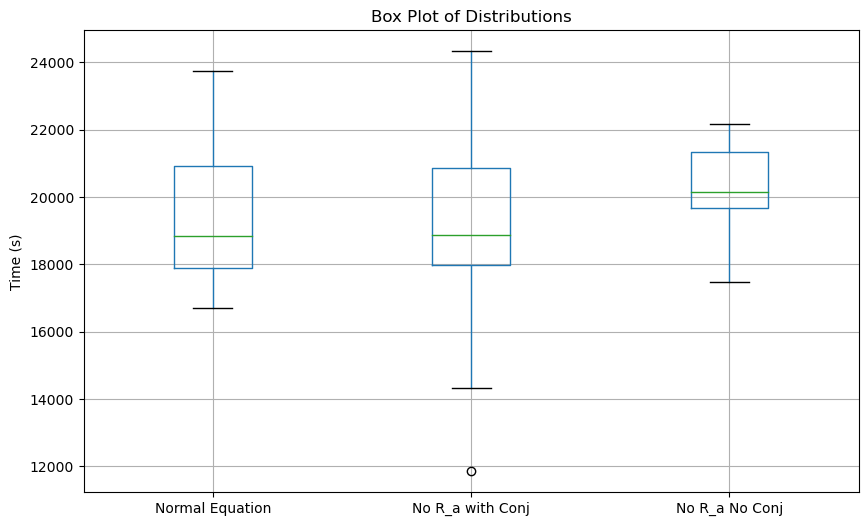

In [44]:
# Visualize the Data
plt.figure(figsize=(10, 6))
df_cleaned.boxplot()
plt.title('Box Plot of Distributions')
plt.ylabel('Time (s)')
plt.show()